### Plotting the ANTI-CCP3 levels across disease status

In [1]:

# load libraries
quiet_library <- function(...) {
    suppressPackageStartupMessages(library(...))
}
quiet_library(hise)
quiet_library(dplyr)
quiet_library(tidyr)
quiet_library(tibble)
quiet_library(forcats)
quiet_library(stats)
quiet_library(qvalue)
quiet_library(dunn.test)
quiet_library(ggplot2)
quiet_library(ggrepel)
quiet_library(ggpubr)
quiet_library(viridis)
quiet_library(RColorBrewer)
quiet_library(rstatix)
options(warn = -1)



Warning message:
“package ‘dunn.test’ was built under R version 4.3.3”


## Read in metadata

In [2]:
meta_uuid <- '32b8bb9c-4834-4e5c-9b3a-7939b3b7f057'

In [3]:
meta_file <- cacheFiles(list(meta_uuid))

meta <- read.csv(meta_file, 
                 header = T, stringsAsFactors = F)

nrow(meta)

[1] "downloading fileID 32b8bb9c-4834-4e5c-9b3a-7939b3b7f057"


[1] 157

In [4]:
# conv <- c('CU1003', 'CU1007', 'CU1009', 'CU1010', 'CU1015', 'CU1021', 'CU1029', 
#           'CU1033', 'CU1037', 'CU1039', 'CU1044', 'CU1050', 'CU1052', 'CU1053', 
#           'SD1003', 'SD1007')

# outCols <- c('Status_Long')

In [5]:
# filter converter id
converter_id = meta %>% filter(!is.na(Status_Long))%>%distinct(subject.subjectGuid)%>%pull(subject.subjectGuid)

In [6]:
# filter samples to baseline
meta_baseline <- meta %>% #filter(!is.na(Status_Xsec))%>% 
    filter(!(Status_Xsec=='early_RA' & Status_Long%in% c('conversion', 'pre')) &
          sample.sampleKitGuid != 'KT04113')%>% # remove duplicate CU1009 (post-conversion) entry to match other analyses
    distinct(subject.subjectGuid, .keep_all = TRUE)%>%
    mutate(status_converter = case_when(Status_Xsec=='at_risk' & Status_Long=='pre' ~ 'converter', 
                                        Status_Xsec=='at_risk' & is.na(Status_Long) ~ 'non_converter',
                                       TRUE ~ Status_Xsec)) %>% 
    mutate(Status=factor(recode(status_converter, 'ALTRA_healthy'='HC1', 
                                'non_converter'='NONC', 'converter'='CONV', 'early_RA'='ERA'
                               ), levels = c('HC1', 'NONC', 'CONV', 'ERA')))
           
    # filter(Status %in% c('ALTRA_healthy', 'non_converter', 'converter', 'early_RA'), # remove original at_risk distinction
    #        sample.sampleKitGuid != 'KT04113') # remove duplicate CU1009 (post-conversion) entry to match other analyses

In [7]:
meta_baseline %>% group_by(Status, Status_Xsec)%>%tally()
meta_baseline%>%filter(is.na(anti_ccp3_finalCombined))

Status,Status_Xsec,n
<fct>,<chr>,<int>
HC1,ALTRA_healthy,38
NONC,at_risk,31
CONV,at_risk,14
ERA,early_RA,11


Status_Xsec,Status_Long,sample.sampleKitGuid,sample.visitName,sample.visitDetails,sample.drawDate,sample.daysSinceFirstVisit,subject.subjectGuid,subject.biologicalSex,subject.birthYear,⋯,record_id...123,BMI,CMV_Status_Subj,CMV_Value_Subj,anti_ccp3_finalCombined,days_to_conversion,age_conv,bmi_conv,status_converter,Status
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<int>,⋯,<lgl>,<dbl>,<chr>,<dbl>,<int>,<int>,<int>,<dbl>,<chr>,<fct>
ALTRA_healthy,NA,KT02298,Flu Year 1 Stand-Alone,N/A - Flu-Series Timepoint Only,2022-09-01,0,SD1026,Female,1965,⋯,NA,20.56127,NA,NA,NA,NA,NA,NA,ALTRA_healthy,HC1
ALTRA_healthy,NA,KT04659,RA Year 4 Visit 1,N/A - on-going collection,2023-05-01,0,CU1100,Female,1978,⋯,NA,22.19201,NA,NA,NA,NA,NA,NA,ALTRA_healthy,HC1


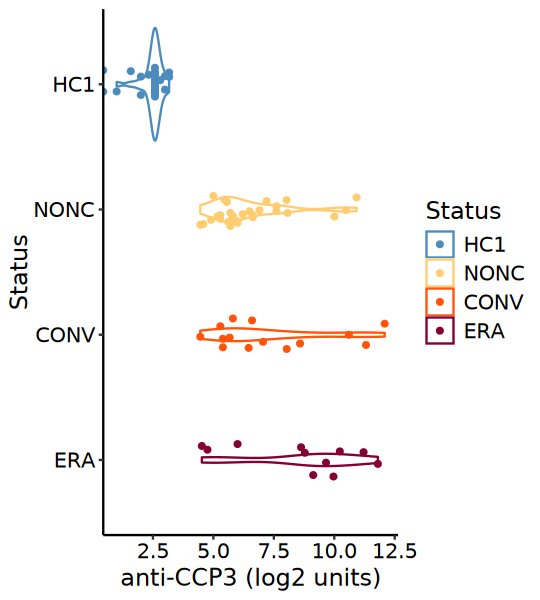

In [8]:
options(repr.plot.width = 4.5, repr.plot.height = 5)

pal3 = c("#4C8CBD","#FFCD70", "#FF540A","#840032")

# Use position_jitterdodge with a set jitter width and dodge width
pl_vl_rc <- ggplot(meta_baseline, aes(x = log2(anti_ccp3_finalCombined), y = Status,  color = Status)) +
  geom_violin() +  # Adjust the width of the violins
  geom_point(position = position_jitterdodge(jitter.width = 0.8, dodge.width =0.9), size = 1.2) +  # Apply controlled jitter
  theme_classic() +
  labs(x = "anti-CCP3 (log2 units)", y = "Status", color = "Status") +
  theme(
    axis.text = element_text(size = 12, color='black'),  # Adjust x and y axis text properties
    axis.title = element_text(size = 14, color='black'),  # Adjust axis title properties
    legend.text = element_text(size = 12, color='black'),  # Adjust legend text properties
    legend.title = element_text(size = 14, color='black'),  # Adjust legend title properties
    panel.grid.minor = element_blank()  # Remove minor grid lines
  ) +
  scale_color_manual(values = pal3)+
scale_y_discrete(limits=rev)

# Display the plot
pl_vl_rc

# Save the plot
ggsave("/home/workspace/private/ra-cohort-ide/ALTRA_revision/Fig_1B_Xsec_ViolinPlot_UPDATED.pdf", 
       plot = pl_vl_rc, width = 4, height = 4, units = "in")


In [9]:
kruskal.test(anti_ccp3_finalCombined ~ Status,
             data = meta_baseline)


	Kruskal-Wallis rank sum test

data:  anti_ccp3_finalCombined by Status
Kruskal-Wallis chi-squared = 68.271, df = 3, p-value = 1.001e-14


In [10]:
meta_baseline %>% dunn_test(anti_ccp3_finalCombined~Status, 
          p.adjust.method  = 'BH' )

,.y.,group1,group2,n1,n2,statistic,p,p.adj,p.adj.signif
,<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<chr>
1,anti_ccp3_finalCombined,HC1,NONC,36,31,6.5024612,7.901639e-11,4.740983e-10,****
2,anti_ccp3_finalCombined,HC1,CONV,36,14,5.6560774,1.548716e-08,3.097432e-08,****
3,anti_ccp3_finalCombined,HC1,ERA,36,11,6.0728486,1.256609e-09,3.769828e-09,****
4,anti_ccp3_finalCombined,NONC,CONV,31,14,0.5846201,5.588032e-01,5.588032e-01,ns
5,anti_ccp3_finalCombined,NONC,ERA,31,11,1.4215850,1.551468e-01,2.327201e-01,ns
6,anti_ccp3_finalCombined,CONV,ERA,14,11,0.7710322,4.406878e-01,5.288254e-01,ns


In [11]:
sessionInfo()

R version 4.3.2 (2023-10-31)
Platform: x86_64-conda-linux-gnu (64-bit)
Running under: Ubuntu 22.04.5 LTS

Matrix products: default
BLAS/LAPACK: /home/workspace/environment/seurat_v5/lib/libopenblasp-r0.3.24.so;  LAPACK version 3.11.0

locale:
 [1] LC_CTYPE=C.UTF-8    LC_NUMERIC=C        LC_TIME=C          
 [4] LC_COLLATE=C        LC_MONETARY=C       LC_MESSAGES=C      
 [7] LC_PAPER=C          LC_NAME=C           LC_ADDRESS=C       
[10] LC_TELEPHONE=C      LC_MEASUREMENT=C    LC_IDENTIFICATION=C

time zone: America/Los_Angeles
tzcode source: system (glibc)

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

other attached packages:
 [1] rstatix_0.7.2      RColorBrewer_1.1-3 viridis_0.6.4      viridisLite_0.4.2 
 [5] ggpubr_0.6.0       ggrepel_0.9.4      ggplot2_3.5.1      dunn.test_1.3.6   
 [9] qvalue_2.34.0      forcats_1.0.0      tibble_3.2.1       tidyr_1.3.0       
[13] dplyr_1.1.3        hise_2.16.0       

loaded via a namespace 